# Notebook 06 - Risk Classification

Predicting academic risk on DS1, in two framings: the full three-way level
(Low / Moderate / High) and a binary High-Risk-vs-rest that the app uses for the
at-risk flag. Logistic regression, random forest, XGBoost, with SMOTE checked on
the minority class.


Features and target come from the preprocessor: 62 engineered features,
stratified 960/240 split, target coded 0/1/2.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tabulate import tabulate

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "ml" / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml import config
from ml.classification import AcademicRiskClassifier
from ml.preprocessing import prepare_primary_data

sns.set_theme(style="whitegrid")

data = prepare_primary_data(save=False)
data["X_train"].shape, data["y_train"].value_counts(normalize=True).round(3).to_dict()

((960, 62), {1: 0.477, 2: 0.376, 0: 0.147})

## Multiclass (Low / Moderate / High)

Low Risk is only ~15% of the data, under the 25% threshold, so SMOTE is applied
to the training split and evaluated against the un-resampled baseline.

In [2]:
multiclass = AcademicRiskClassifier(mode="multiclass").fit(
    data["X_train"], data["y_train"], data["X_test"], data["y_test"]
)
print("Before SMOTE:")
print(tabulate(multiclass.metrics_before_, headers="keys", tablefmt="github"))
print("\nAfter SMOTE:")
print(tabulate(multiclass.metrics_after_, headers="keys", tablefmt="github"))
print(f"\nChosen: {multiclass.best_name_} (SMOTE used: {multiclass.best_used_smote_})")

Before SMOTE:
|                     |   accuracy |   f1_macro |   precision_macro |   recall_macro |   roc_auc |
|---------------------|------------|------------|-------------------|----------------|-----------|
| logistic_regression |      0.967 |      0.957 |             0.976 |          0.943 |     0.988 |
| random_forest       |      0.875 |      0.801 |             0.921 |          0.77  |     0.953 |
| xgboost             |      0.938 |      0.924 |             0.925 |          0.922 |     0.982 |

After SMOTE:
|                     |   accuracy |   f1_macro |   precision_macro |   recall_macro |   roc_auc |
|---------------------|------------|------------|-------------------|----------------|-----------|
| logistic_regression |      0.954 |      0.94  |             0.94  |          0.941 |     0.989 |
| random_forest       |      0.854 |      0.813 |             0.87  |          0.788 |     0.953 |
| xgboost             |      0.946 |      0.93  |             0.932 |          0.

SMOTE doesn't help here. The best model is logistic regression without
resampling; SMOTE nudged the weaker tree models' minority recall a little but
slightly lowered the strong linear model's macro F1, so I keep the un-resampled
version. When the classes are already close to separable, oversampling mostly
just perturbs the majority fit.

Those numbers are high enough that I want to rule out a leak before
trusting them. If one feature basically *is* the label, a depth-1 stump on it
would already score near the top.

In [3]:
from sklearn.tree import DecisionTreeClassifier

stumps = []
for column in data["X_train"].columns:
    stump = DecisionTreeClassifier(max_depth=1, random_state=config.RANDOM_SEED)
    stump.fit(data["X_train"][[column]], data["y_train"])
    stumps.append((column, round(stump.score(data["X_test"][[column]], data["y_test"]), 3)))

shallow = DecisionTreeClassifier(max_depth=3, random_state=config.RANDOM_SEED)
shallow.fit(data["X_train"], data["y_train"])

print("Top single-feature (depth-1) accuracies:")
for name, score in sorted(stumps, key=lambda r: -r[1])[:5]:
    print(f"  {name:24s} {score}")
print(f"\ndepth-3 tree (all features): {round(shallow.score(data['X_test'], data['y_test']), 3)}")

Top single-feature (depth-1) accuracies:
  cgpa_category            0.637
  study_consistency        0.6
  procrastination_level    0.562
  study_hours_daily        0.546
  attendance_percentage    0.525

depth-3 tree (all features): 0.775


No single feature carries it (best stump is cgpa_category at ~0.64), and a
shallow tree only reaches ~0.78. So the accuracy isn't a giveaway column. It
comes from many behavioural features combining almost linearly, which is exactly
why logistic regression outperforms the trees. The most likely explanation is
that the dataset's risk label was assigned from a rubric over these same
responses, so the task is partly recovering that rubric. 

               precision    recall  f1-score   support

     Low Risk       1.00      0.86      0.92        35
Moderate Risk       0.95      0.98      0.97       114
    High Risk       0.98      0.99      0.98        91

     accuracy                           0.97       240
    macro avg       0.98      0.94      0.96       240
 weighted avg       0.97      0.97      0.97       240



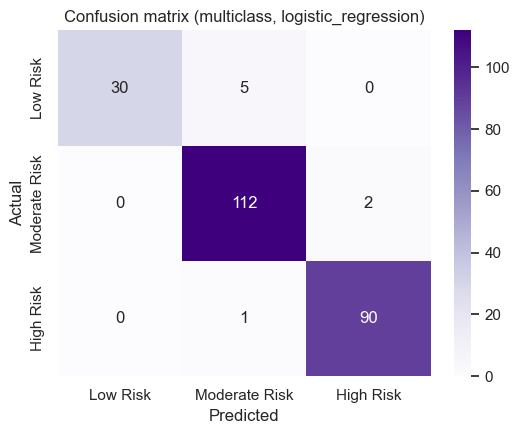

In [4]:
print(multiclass.classification_report_text(data["X_test"], data["y_test"]))
multiclass.plot_confusion_matrix(
    data["X_test"], data["y_test"], config.PLOTS_DIR / "classification_confusion_multiclass.png"
);

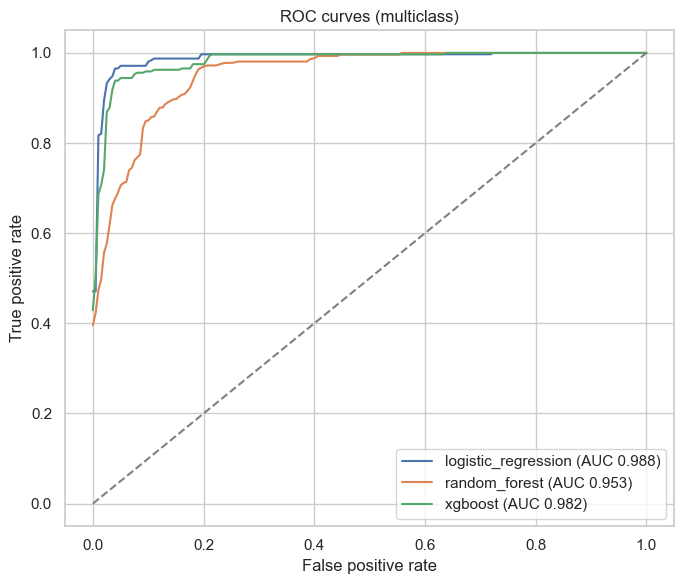

In [5]:
multiclass.plot_roc_curves(
    data["X_test"], data["y_test"], config.PLOTS_DIR / "classification_roc_multiclass.png"
);

## Binary (High Risk vs rest)

This is the flag the product cares about. High Risk is ~38% of the data, above
the threshold, so no SMOTE. Same three models, plus a precision-recall curve and
a threshold sweep since a single operating point matters here.

In [6]:
binary = AcademicRiskClassifier(mode="binary").fit(
    data["X_train"], data["y_train"], data["X_test"], data["y_test"]
)
print(tabulate(binary.metrics_, headers="keys", tablefmt="github"))
print(f"\nChosen: {binary.best_name_} | optimal F1 threshold: {binary.optimal_threshold_}")

|                     |   accuracy |   f1_macro |   precision_macro |   recall_macro |   roc_auc |
|---------------------|------------|------------|-------------------|----------------|-----------|
| logistic_regression |      0.988 |      0.987 |             0.986 |          0.988 |     0.995 |
| random_forest       |      0.963 |      0.96  |             0.961 |          0.959 |     0.984 |
| xgboost             |      0.988 |      0.987 |             0.986 |          0.988 |     0.995 |

Chosen: logistic_regression | optimal F1 threshold: 0.4


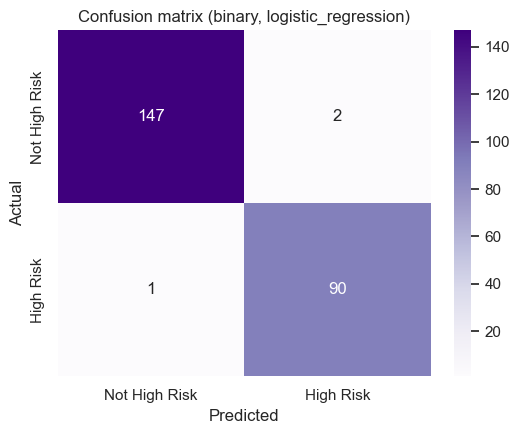

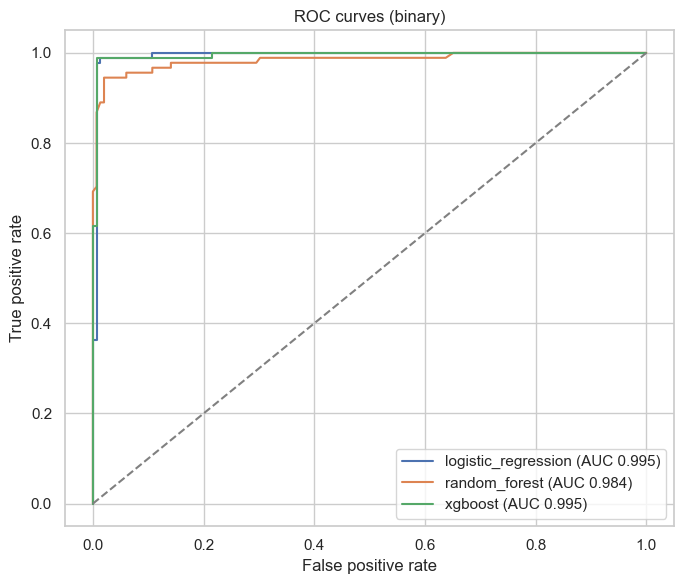

In [7]:
binary.plot_confusion_matrix(
    data["X_test"], data["y_test"], config.PLOTS_DIR / "classification_confusion_binary.png"
)
binary.plot_roc_curves(
    data["X_test"], data["y_test"], config.PLOTS_DIR / "classification_roc_binary.png"
);

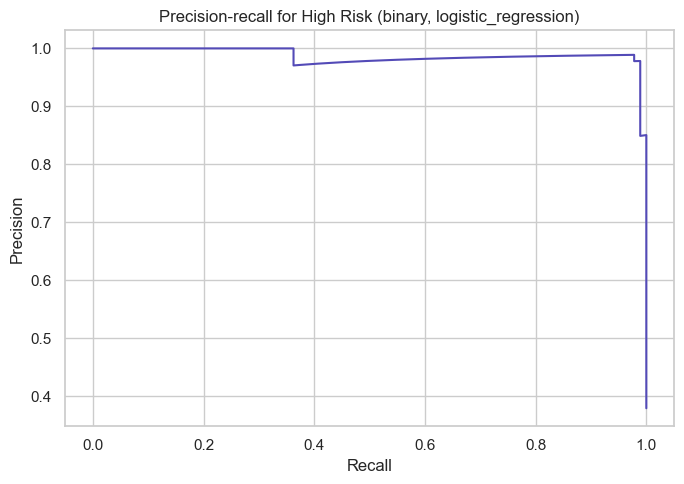

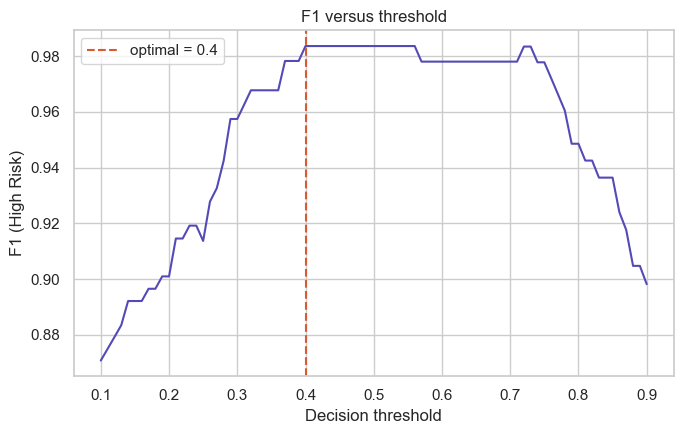

In [8]:
binary.plot_precision_recall(
    data["X_test"], data["y_test"], config.PLOTS_DIR / "classification_pr_binary.png"
)
binary.plot_threshold_tuning(
    data["X_test"], data["y_test"], config.PLOTS_DIR / "classification_threshold_binary.png"
);

## A note on cross-dataset validation

The brief called for running the classifier on DS3 and DS4 with shared features.
In practice that isn't feasible here: DS1's 62 features are behavioural survey
responses, while DS3 and DS4 are numeric performance-factor datasets with an
exam-score outcome and no risk label. There is almost no shared feature space and
no target to score against, so a transferred risk classifier would be
meaningless. Cross-dataset robustness is therefore demonstrated on the
regression track (Step 11), where the datasets genuinely share features and an
outcome. I'd rather say that than manufacture a number.

Save both models. Multiclass drives the risk level, binary drives the
at-risk probability and flag.

In [9]:
multiclass.save()
binary.save()

## Key takeaways

- Logistic regression wins both framings: multiclass macro F1 ~0.96, binary
  ROC-AUC ~0.995. The relationship is close to linear in the encoded feature
  space, which is why it beats the trees.
- SMOTE was evaluated because Low Risk is under 25%, but it didn't improve the
  best model, so the un-resampled version is kept. The comparison is reported
  either way.
- The high accuracy is not a single-feature leak; it reflects a label that is
  largely a composite of the behavioural responses. Reported plainly.
- Classifier cross-dataset transfer isn't feasible with these datasets, so that
  claim rests on the regression track.